<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/POTENTIAL_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df = pd.DataFrame(pd.read_csv('/content/StudentPerformanceFactors.csv'))
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [5]:
drop_list = ['Distance_from_Home', 'Parental_Education_Level']
#df = df.drop(columns = drop_list)
df.shape

(6607, 20)

Missing data

In [6]:
df.isnull().sum()

,0
Hours_Studied,2
Attendance,2
Parental_Involvement,1
Access_to_Resources,2
Extracurricular_Activities,2
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,1
Internet_Access,1
Tutoring_Sessions,1


Befrore dropping data examine (high num missing) variables' exam scores for skewness etc

<Axes: title={'center': 'Missing Teacher Quality Exam Score Distribution'}, xlabel='Scores', ylabel='Frequency'>

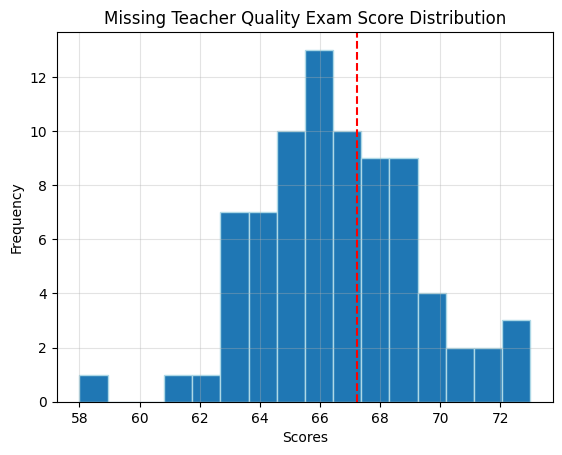

In [7]:
#filter out nulls for teacher quality
#plot shapes are indicative of not much skew
plt.title("Missing Teacher Quality Exam Score Distribution")
null_teacher_scores = df[df['Teacher_Quality'].isnull()]['Exam_Score']
plt.xlabel('Scores')
plt.ylabel("Frequency")
plt.grid(alpha = 0.35)

#overall mean from all other data
non_null_teacher_scores_mean = df[~df['Teacher_Quality'].isnull()]['Exam_Score'].mean()

plt.axvline(non_null_teacher_scores_mean, color = 'red', linestyle = '--')
null_teacher_scores.hist(bins = 16, edgecolor = 'lightblue')

Overlap missing

In [8]:
missing_overlap_pel = df['Parental_Education_Level'].isnull()
missing_overlap_dfh = df['Distance_from_Home'].isnull()

missing_overlap = pd.crosstab(missing_overlap_pel, missing_overlap_dfh)
print(missing_overlap)

Distance_from_Home        False  True 
Parental_Education_Level              
False                      6449     68
True                         90      0


Drop null rows

In [9]:
df = df.dropna()

EDA including category types and exploration

In [10]:
cats = df.select_dtypes(include = 'object').astype('category')
catcols = cats.columns.tolist()

Descriptive stats for w and w/out special needs

In [11]:
no_needs_df = df[df['Learning_Disabilities'] == 'No']
needs_df = df[df['Learning_Disabilities'] != 'No']

Smaller deviation... was expecting bigger

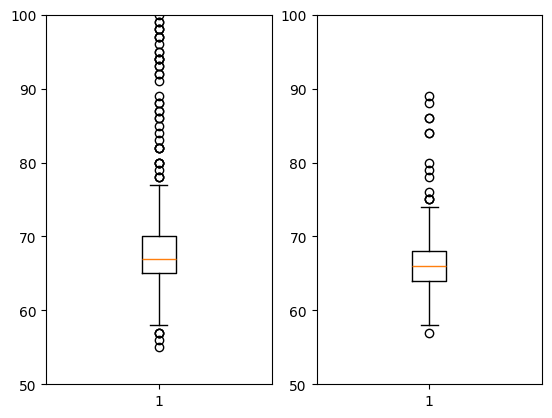

In [12]:
plt.subplot(1, 2, 1)
plt.boxplot(no_needs_df['Exam_Score'])
plt.ylim(50, 100)
plt.subplot(1, 2, 2)
plt.boxplot(needs_df['Exam_Score'])
plt.ylim(50, 100)
plt.show()

Add a y categorical column

<Axes: >

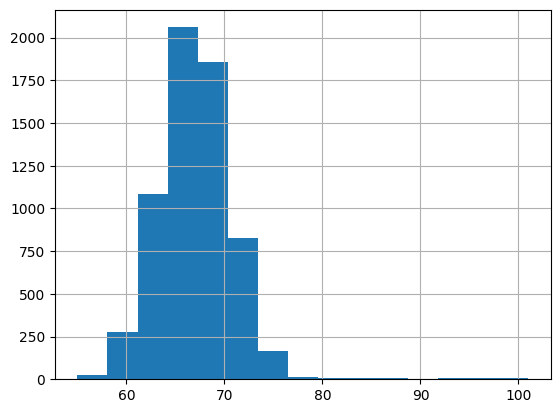

In [13]:
df['Exam_Score'].hist(bins = 15)

In [14]:
df['Exam_Score_cat'] = pd.cut(df['Exam_Score'], bins = 5)

All prep

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Exam_Score'])
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

#categorical: specifically non ordinal
from sklearn.preprocessing import OneHotEncoder
non_ordinal_train = X_train[['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Peer_Influence', 'Gender']]
non_ordinal_test = X_test[['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Peer_Influence', 'Gender']]
ohe = OneHotEncoder(handle_unknown='ignore')
non_ordinal_train_enc = ohe.fit_transform(non_ordinal_train)
non_ordinal_test_enc = ohe.transform(non_ordinal_test)

ohe_feature_names = ohe.get_feature_names_out(non_ordinal_train.columns)
non_ordinal_train_df = pd.DataFrame(non_ordinal_train_enc.toarray(), columns=ohe_feature_names, index=X_train.index)
non_ordinal_test_df = pd.DataFrame(non_ordinal_test_enc.toarray(), columns=ohe_feature_names, index=X_test.index)

#categorical: ordinal
ordinal = X[['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Parental_Education_Level', 'Distance_from_Home', 'Teacher_Quality']]
ordinal_train = X_train[['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Parental_Education_Level', 'Distance_from_Home', 'Teacher_Quality']]
ordinal_test = X_test[['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Parental_Education_Level', 'Distance_from_Home', 'Teacher_Quality']]
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder()
ordinal_train_enc = ord_enc.fit_transform(ordinal_train)
ordinal_test_enc = ord_enc.transform(ordinal_test)

ordinal_train_df = pd.DataFrame(ordinal_train_enc, columns=ordinal_train.columns, index=X_train.index)
ordinal_test_df = pd.DataFrame(ordinal_test_enc, columns=ordinal_test.columns, index=X_test.index)

#back together
X_train_enc = pd.concat([non_ordinal_train_df, ordinal_train_df], axis = 1)
X_test_enc = pd.concat([non_ordinal_test_df, ordinal_test_df], axis = 1)

#scaling
num_cols_train = X_train.select_dtypes(include = ['number'])
num_cols_test = X_test.select_dtypes(include = ['number'])
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(num_cols_train)
X_test_scaled = ss.transform(num_cols_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = num_cols_train.columns, index = X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = num_cols_test.columns, index = X_test.index)

#combine all
X_train_final = pd.concat([non_ordinal_train_df, ordinal_train_df, X_train_scaled_df], axis = 1)
X_test_final = pd.concat([non_ordinal_test_df, ordinal_test_df, X_test_scaled_df], axis = 1)

---
Idea 1: special needs focus

In [16]:
X_train_final.describe().iloc[1:-1]

,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Gender_Female,...,Family_Income,Parental_Education_Level,Distance_from_Home,Teacher_Quality,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity
mean,0.404406,0.595594,0.076121,0.923879,0.306255,0.693745,0.213808,0.391031,0.395161,0.423289,...,1.216562,0.895358,1.496656,1.292683,1.118085e-17,-3.329796e-16,-6.988028e-17,-5.730183e-17,-3.878356e-17,5.730183e-17
std,0.490825,0.490825,0.265218,0.265218,0.460982,0.460982,0.410033,0.488029,0.488933,0.494129,...,0.742006,0.704156,0.668410,0.901230,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-3.167033e+00,-1.446285e+01,-2.064942e+00,-1.751172e+00,-1.212102e+00,-2.903569e+00
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,-6.616082e-01,-8.429608e-01,-7.068351e-01,-8.484324e-01,-4.063584e-01,-9.552095e-01
50%,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,2.000000,2.000000,6.505037e-03,2.995123e-03,-2.778188e-02,-1.513399e-02,-4.063584e-01,1.897006e-02
75%,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,2.000000,1.000000,2.000000,2.000000,6.746183e-01,8.489511e-01,6.512713e-01,8.876060e-01,3.993850e-01,9.931496e-01


Factor analysis

In [ ]:
import sys
!{sys.executable} -m pip install factor_analyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(X_train_final)
chi_square_value, p_value

from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(X_train_final)
kmo_model

Collinearity

<Axes: >

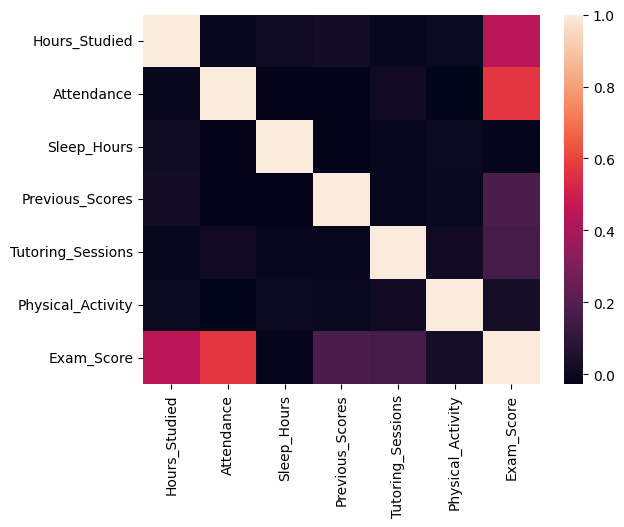

In [27]:
heat_corr_matrix = sns.heatmap(df.select_dtypes(include = ['number']).corr())
heat_corr_matrix

Categorical correlation

ANOVA for continuous and categorical correlation

---
BIN

PCA --> SVC

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

from sklearn.svm import SVC
svc = SVC(kernel = 'rbf', C = 1)
svc.fit(X_train_pca, y_train)
preds = svc.predict(X_test_pca)
print(preds[0:10])

from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(svc, X_train_pca, response_method="predict", alpha=0.5)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=20, edgecolors="k")
plt.show()

Lasso